In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q datasets PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK3_WORK_ROOT = (
    PROJECT_ROOT / "task3"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

SOURCE_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

CHECKPOINT_PATH = (
    TASK3_WORK_ROOT
    / "checkpoints/dan_dg_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import yaml

import matplotlib.pyplot as plt

import pandas as pd

import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.backbone import (
    count_trainable_parameters,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task3.data.source_loaders import (
    build_task3_source_datasets,
    build_task3_source_loaders,
)

from task3.train import (
    train_task3_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK3_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK3_REPO_ROOT
    / "configs/dan_dg.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config["method"]["name"],
)

print(
    "MMD weight:",
    method_config["method"][
        "mmd_weight"
    ],
)

print(
    "Alignment:",
    method_config["method"][
        "alignment"
    ],
)

print(
    "Target images allowed:",
    base_config["selection"][
        "use_target_images"
    ],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: dan_dg
MMD weight: 1.0
Alignment: mean_pairwise_source_mmd
Target images allowed: False


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

pacs_protocol = load_pacs_protocol(
    SOURCE_SPLIT_PATH
)

source_datasets = (
    build_task3_source_datasets(
        dataset=pacs_dataset,
        protocol=pacs_protocol,
    )
)

print(
    "Dataset groups:",
    list(source_datasets.keys()),
)

print(
    "Training domains:",
    list(
        source_datasets[
            "source_train"
        ].keys()
    ),
)

print(
    "Target dataset created:",
    any(
        "target" in key.lower()
        for key in (
            source_datasets.keys()
        )
    ),
)

Dataset groups: ['source_train', 'source_validation']
Training domains: ['photo', 'art_painting', 'cartoon']
Target dataset created: False


In [6]:
source_loaders = (
    build_task3_source_loaders(
        datasets=source_datasets,
        source_batch_size=(
            base_config["batching"][
                "examples_per_source_domain"
            ]
        ),
        evaluation_batch_size=(
            base_config["batching"][
                "evaluation_batch_size"
            ]
        ),
        number_of_workers=(
            base_config["batching"][
                "number_of_workers"
            ]
        ),
        seed=SEED,
    )
)

print(
    "Steps per epoch:",
    source_loaders[
        "steps_per_epoch"
    ],
)

print(
    "Examples per domain per step:",
    base_config["batching"][
        "examples_per_source_domain"
    ],
)

print(
    "Total source batch size:",
    (
        base_config["batching"][
            "examples_per_source_domain"
        ]
        * len(
            source_loaders[
                "source_train"
            ]
        )
    ),
)

Steps per epoch: 234
Examples per domain per step: 8
Total source batch size: 24


In [7]:
set_seed(SEED)

model = PACSClassifier(
    number_of_classes=7
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=(
        base_config["optimization"][
            "learning_rate"
        ]
    ),
    weight_decay=(
        base_config["optimization"][
            "weight_decay"
        ]
    ),
)

selector = SourceValidationSelector(
    checkpoint_path=CHECKPOINT_PATH,
    patience=(
        base_config["optimization"][
            "early_stopping_patience"
        ]
    ),
)

print(
    "Trainable parameters:",
    count_trainable_parameters(
        model
    ),
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)

print(
    "MMD domain pairs:",
    method_config["method"][
        "source_domain_pairs"
    ],
)

Trainable parameters: 11180103
Checkpoint: /content/drive/MyDrive/ATML/PA1/task3/checkpoints/dan_dg_best.pt
MMD domain pairs: [['photo', 'art_painting'], ['photo', 'cartoon'], ['art_painting', 'cartoon']]


In [8]:
training_result = (
    train_task3_method(
        method_name="dan_dg",
        model=model,
        loaders=source_loaders,
        optimizer=optimizer,
        selector=selector,
        device=DEVICE,
        maximum_epochs=(
            base_config[
                "optimization"
            ]["maximum_epochs"]
        ),
        mmd_weight=(
            method_config[
                "method"
            ]["mmd_weight"]
        ),
        gradient_clip_norm=(
            base_config[
                "optimization"
            ]["gradient_clip_norm"]
        ),
        number_of_classes=7,
    )
)

model = training_result["model"]

training_history = (
    training_result["history"]
)

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_training_history.csv"
)

training_history.to_csv(
    history_path,
    index=False,
)

print()
print(
    "Selected epoch:",
    selected_checkpoint["epoch"],
)

print(
    "Selected mean source macro-F1:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

dan_dg epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=2.5340, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 2:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 2: train loss=2.4612, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 3:   0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch 4: train loss=2.4880, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 5: train loss=2.4978, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 6:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 6: train loss=2.5161, mean validation macro-F1=0.0507, best=0.0507
Early stopping triggered.

Selected epoch: 1
Selected mean source macro-F1: 0.05066996495567924
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/dan_dg_training_history.csv


In [9]:
source_validation_results = (
    evaluate_source_domains(
        model=model,
        validation_loaders=(
            source_loaders[
                "source_validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=7,
    )
)

source_result_rows = []

for domain_name, metrics in (
    source_validation_results[
        "domains"
    ].items()
):
    source_result_rows.append(
        {
            "method": "dan_dg",
            "domain": domain_name,
            "accuracy": (
                metrics["accuracy"]
            ),
            "macro_f1": (
                metrics["macro_f1"]
            ),
            "loss": metrics["loss"],
            "number_of_samples": (
                metrics[
                    "number_of_samples"
                ]
            ),
        }
    )

source_result_table = pd.DataFrame(
    source_result_rows
)

source_result_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_source_validation.csv"
)

source_result_table.to_csv(
    source_result_path,
    index=False,
)

print(
    source_result_table.to_string(
        index=False
    )
)

print()
print(
    "Mean source accuracy:",
    source_validation_results[
        "aggregate"
    ]["mean_accuracy"],
)

print(
    "Mean source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["mean_macro_f1"],
)

print(
    "Worst source accuracy:",
    source_validation_results[
        "aggregate"
    ]["worst_accuracy"],
)

print(
    "Worst source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["worst_macro_f1"],
)

method       domain  accuracy  macro_f1     loss  number_of_samples
dan_dg        photo  0.257485  0.058503 1.937238                334
dan_dg art_painting  0.219512  0.051429 1.943101                410
dan_dg      cartoon  0.172708  0.042078 1.946018                469

Mean source accuracy: 0.21656837139595686
Mean source macro-F1: 0.05066996495567924
Worst source accuracy: 0.17270788912579957
Worst source macro-F1: 0.04207792207792208


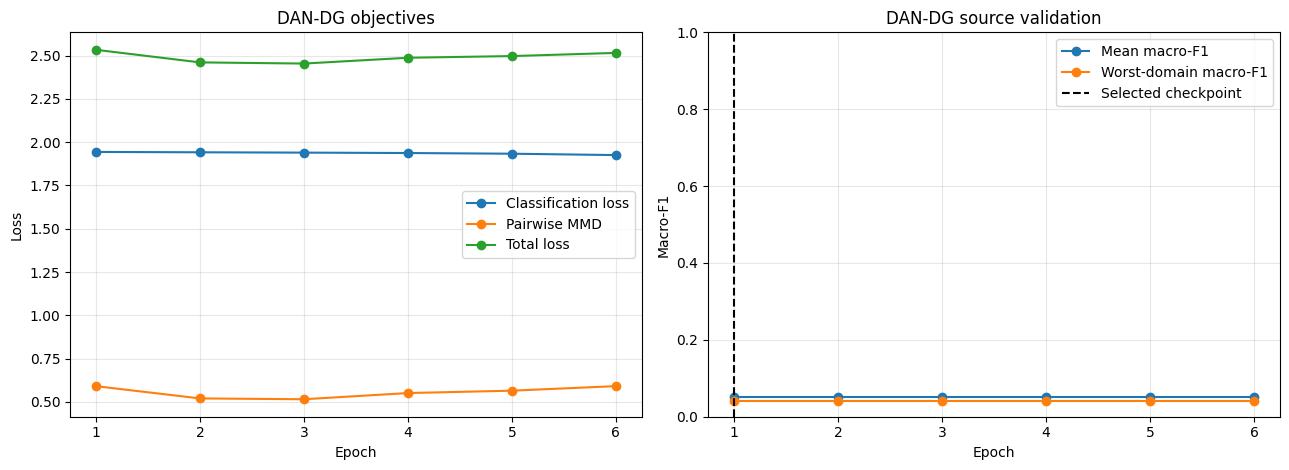

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/dan_dg_training_curves.png


In [10]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_classification_loss"
    ],
    marker="o",
    label="Classification loss",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_alignment_loss"
    ],
    marker="o",
    label="Pairwise MMD",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_total_loss"
    ],
    marker="o",
    label="Total loss",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(
    "DAN-DG objectives"
)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history[
        "mean_source_validation_macro_f1"
    ],
    marker="o",
    label="Mean macro-F1",
)

axes[1].plot(
    training_history["epoch"],
    training_history[
        "worst_source_validation_macro_f1"
    ],
    marker="o",
    label="Worst-domain macro-F1",
)

axes[1].axvline(
    selected_checkpoint["epoch"],
    color="black",
    linestyle="--",
    label="Selected checkpoint",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title(
    "DAN-DG source validation"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "dan_dg_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [11]:
dan_dg_metadata = {
    "method": "dan_dg",
    "seed": SEED,
    "mmd_weight": float(
        method_config["method"][
            "mmd_weight"
        ]
    ),
    "alignment": (
        "mean pairwise source-domain MMD"
    ),
    "source_domain_pairs": (
        method_config["method"][
            "source_domain_pairs"
        ]
    ),
    "bandwidth_multipliers": (
        method_config["method"][
            "bandwidth_multipliers"
        ]
    ),
    "gradient_clip_norm": float(
        base_config["optimization"][
            "gradient_clip_norm"
        ]
    ),
    "selected_epoch": int(
        selected_checkpoint["epoch"]
    ),
    "selection_metric": (
        selected_checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "checkpoint_filename": (
        CHECKPOINT_PATH.name
    ),
    "target_images_loaded": False,
    "target_labels_used": False,
    "source_validation": {
        domain_name: {
            "accuracy": float(
                metrics["accuracy"]
            ),
            "macro_f1": float(
                metrics["macro_f1"]
            ),
            "loss": float(
                metrics["loss"]
            ),
            "number_of_samples": int(
                metrics[
                    "number_of_samples"
                ]
            ),
        }
        for domain_name, metrics
        in source_validation_results[
            "domains"
        ].items()
    },
    "aggregate_source_validation": {
        key: float(value)
        for key, value
        in source_validation_results[
            "aggregate"
        ].items()
    },
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        dan_dg_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        dan_dg_metadata,
        indent=2,
    )
)

{
  "method": "dan_dg",
  "seed": 6304,
  "mmd_weight": 1.0,
  "alignment": "mean pairwise source-domain MMD",
  "source_domain_pairs": [
    [
      "photo",
      "art_painting"
    ],
    [
      "photo",
      "cartoon"
    ],
    [
      "art_painting",
      "cartoon"
    ]
  ],
  "bandwidth_multipliers": [
    0.5,
    1.0,
    2.0
  ],
  "gradient_clip_norm": 1.0,
  "selected_epoch": 1,
  "selection_metric": "mean_source_validation_macro_f1",
  "selection_score": 0.05066996495567924,
  "checkpoint_filename": "dan_dg_best.pt",
  "target_images_loaded": false,
  "target_labels_used": false,
  "source_validation": {
    "photo": {
      "accuracy": 0.25748502994011974,
      "macro_f1": 0.058503401360544216,
      "loss": 1.9372384191273215,
      "number_of_samples": 334
    },
    "art_painting": {
      "accuracy": 0.21951219512195122,
      "macro_f1": 0.05142857142857143,
      "loss": 1.9431012874696312,
      "number_of_samples": 410
    },
    "cartoon": {
      "accuracy"